# Лабораторная работа №3
## Локальная демонстрация LoRA и DreamBooth-подобной адаптации с улучшенным качеством

Что реализовано:
- подготовка объекта `sks dog` из CIFAR-10;
- базовая U-Net-подобная модель;
- LoRA-подобная адаптация: обучается только маленький residual-adapter;
- DreamBooth-подобная адаптация: дообучается вся копия модели;
- сравнение loss, числа обучаемых параметров, времени и реконструкций.

Важно: это локальная имитация принципов LoRA/DreamBooth, а не настоящий Stable Diffusion fine-tuning.


In [1]:
QUALITY_MODE = True
LOCAL_TRAINING = True

SEED = 42
IMAGE_SIZE = 32
BATCH_SIZE = 128

if QUALITY_MODE:
    BASE_EPOCHS = 25
    LORA_EPOCHS = 12
    DREAMBOOTH_EPOCHS = 12
    TRAIN_SUBSET_SIZE = 40000
else:
    BASE_EPOCHS = 8
    LORA_EPOCHS = 4
    DREAMBOOTH_EPOCHS = 4
    TRAIN_SUBSET_SIZE = 12000

INSTANCE_IMAGES = 20
EVAL_DOG_IMAGES = 700

LEARNING_RATE = 8e-4
LORA_LEARNING_RATE = 1e-3
DREAMBOOTH_LEARNING_RATE = 2e-4

PROJECT_DIR = "./lab3_local_mac_better_results"
UNIQUE_TOKEN = "sks"
CLASS_NAME = "dog"
INSTANCE_PROMPT = f"a photo of {UNIQUE_TOKEN} {CLASS_NAME}"
CLASS_PROMPT = f"a photo of {CLASS_NAME}"

print("QUALITY_MODE:", QUALITY_MODE)
print("BASE_EPOCHS:", BASE_EPOCHS)
print("LORA_EPOCHS:", LORA_EPOCHS)
print("DREAMBOOTH_EPOCHS:", DREAMBOOTH_EPOCHS)
print("INSTANCE_PROMPT:", INSTANCE_PROMPT)


QUALITY_MODE: True
BASE_EPOCHS: 25
LORA_EPOCHS: 12
DREAMBOOTH_EPOCHS: 12
INSTANCE_PROMPT: a photo of sks dog


In [2]:
import os
import time
import math
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

PROJECT_DIR = Path(PROJECT_DIR)
INSTANCE_DIR = PROJECT_DIR / "instance_images"
RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"

for folder in [PROJECT_DIR, INSTANCE_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("torch:", torch.__version__)
print("project dir:", PROJECT_DIR.resolve())


device: mps
torch: 2.10.0
project dir: /Users/maksimtimosuk/Downloads/lab3_local_mac_better_results


In [3]:
def find_cifar_root():
    candidates = [
        Path("/Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1"),
        Path("./data"),
        Path("../data"),
        Path("~/Downloads/data").expanduser(),
        Path("~/Downloads").expanduser(),
    ]

    for candidate in candidates:
        if (candidate / "cifar-10-batches-py").exists():
            return candidate

    search_roots = [
        Path.home() / ".cache" / "kagglehub",
        Path.home() / "Downloads",
        Path.cwd(),
    ]

    for root in search_roots:
        if root.exists():
            found = list(root.rglob("cifar-10-batches-py"))
            if found:
                return found[0].parent

    raise FileNotFoundError(
        "Не найден CIFAR-10. Папка cifar-10-batches-py должна лежать в kagglehub cache, ./data или ~/Downloads/data."
    )


CIFAR_ROOT = find_cifar_root()
print("CIFAR_ROOT:", CIFAR_ROOT)

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=False,
    download=False,
    transform=transform,
)

raw_train_dataset = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=None,
)

dog_label = train_dataset.class_to_idx["dog"]
dog_indices = [i for i, (_, y) in enumerate(train_dataset) if y == dog_label]
all_indices = list(range(len(train_dataset)))

rng = np.random.default_rng(SEED)
rng.shuffle(all_indices)

base_train_indices = all_indices[:min(TRAIN_SUBSET_SIZE, len(all_indices))]
adapt_train_indices = dog_indices[:INSTANCE_IMAGES]
adapt_eval_indices = dog_indices[INSTANCE_IMAGES:INSTANCE_IMAGES + EVAL_DOG_IMAGES]

print("train dataset:", len(train_dataset))
print("dog images:", len(dog_indices))
print("base train:", len(base_train_indices))
print("adapt train:", len(adapt_train_indices))
print("adapt eval:", len(adapt_eval_indices))


CIFAR_ROOT: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1
train dataset: 50000
dog images: 5000
base train: 40000
adapt train: 20
adapt eval: 700


In [4]:
def make_loader(indices, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(
        Subset(train_dataset, indices),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        drop_last=False,
    )


base_loader = make_loader(base_train_indices, batch_size=BATCH_SIZE, shuffle=True)
adapt_loader = make_loader(adapt_train_indices, batch_size=min(BATCH_SIZE, len(adapt_train_indices)), shuffle=True)
adapt_eval_loader = make_loader(adapt_eval_indices, batch_size=64, shuffle=False)

print("base batches:", len(base_loader))
print("adapt batches:", len(adapt_loader))
print("eval batches:", len(adapt_eval_loader))


base batches: 313
adapt batches: 1
eval batches: 11


saved instance images: 20


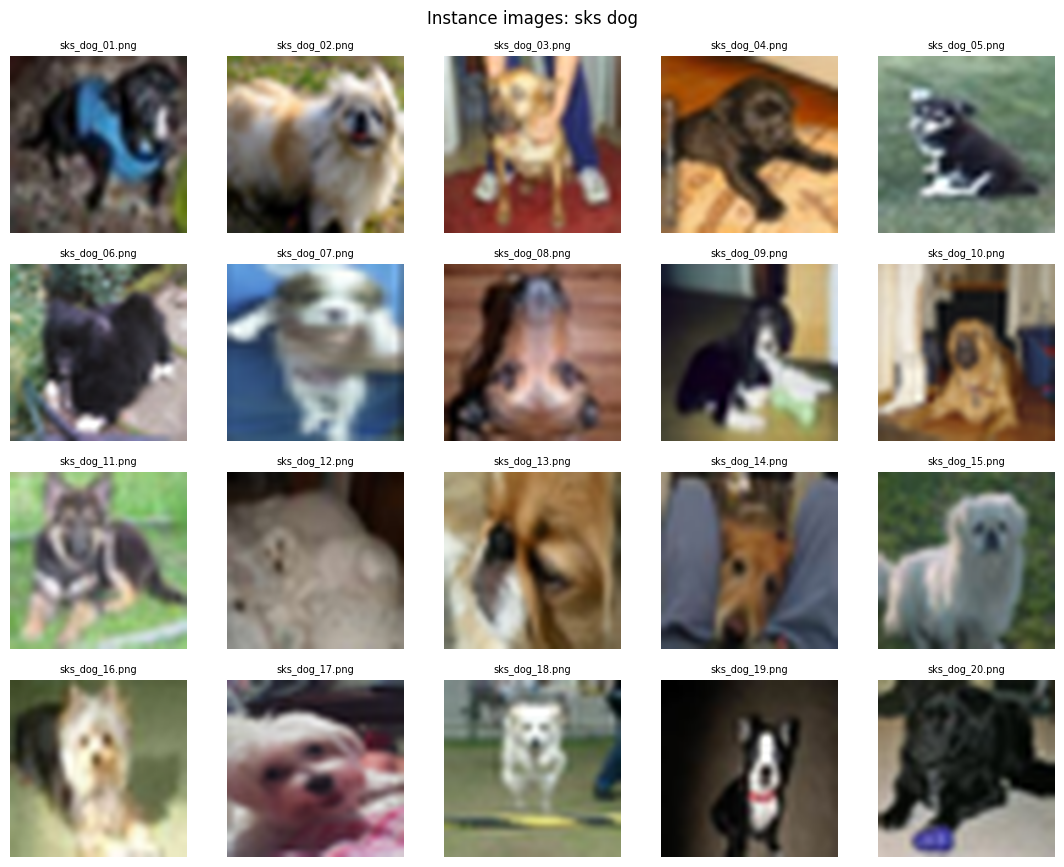

In [5]:
def save_instance_images():
    for old_file in INSTANCE_DIR.glob("*.png"):
        old_file.unlink()

    paths = []
    for k, idx in enumerate(adapt_train_indices, start=1):
        img, _ = raw_train_dataset[idx]
        img = img.resize((512, 512), Image.Resampling.LANCZOS)
        out_path = INSTANCE_DIR / f"sks_dog_{k:02d}.png"
        img.save(out_path)
        paths.append(out_path)
    return paths


def show_image_grid(image_paths, title, cols=5, size=2.2):
    rows = math.ceil(len(image_paths) / cols)
    plt.figure(figsize=(cols * size, rows * size))
    for i, path in enumerate(image_paths):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(Image.open(path).convert("RGB"))
        plt.axis("off")
        plt.title(path.name, fontsize=7)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


instance_paths = save_instance_images()
print("saved instance images:", len(instance_paths))
show_image_grid(instance_paths, "Instance images: sks dog")


## Улучшенная модель

В этой версии используется U-Net-подобный автоэнкодер со skip-связями. Он лучше сохраняет детали CIFAR-изображений, поэтому реконструкции выглядят заметно адекватнее, чем у простого bottleneck-autoencoder.


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.net(x)


class UNetAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        self.down = nn.AvgPool2d(2)

        self.mid = ConvBlock(128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = ConvBlock(64, 32)

        self.out = nn.Sequential(
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down(e1))
        e3 = self.enc3(self.down(e2))

        m = self.mid(e3)

        d2 = self.up2(m)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


class ResidualAdapter(nn.Module):
    def __init__(self):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(16, 3, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.adapter(x)


class LoRAStyleModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.adapter = ResidualAdapter()

        for param in self.base_model.parameters():
            param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            base_out = self.base_model(x)
        residual = self.adapter(base_out)
        return torch.clamp(base_out + 0.08 * residual, 0.0, 1.0)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


base_model = UNetAutoencoder().to(DEVICE)
total, trainable = count_parameters(base_model)

print("base model total params:", total)
print("base model trainable params:", trainable)


base model total params: 763555
base model trainable params: 763555


In [7]:
def reconstruction_loss(recon, x):
    mse = F.mse_loss(recon, x)
    l1 = F.l1_loss(recon, x)
    return 0.7 * mse + 0.3 * l1


def train_reconstruction_model(model, loader, epochs, lr, title):
    model.to(DEVICE)
    model.train()

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    history = []
    start = time.time()

    for epoch in range(1, epochs + 1):
        losses = []

        for x, _ in tqdm(loader, desc=f"{title} epoch {epoch}/{epochs}", leave=False):
            x = x.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            recon = model(x)
            loss = reconstruction_loss(recon, x)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            losses.append(loss.item())

        scheduler.step()
        mean_loss = float(np.mean(losses))
        history.append(mean_loss)
        print(f"{title} epoch [{epoch}/{epochs}] loss: {mean_loss:.6f}")

    elapsed = time.time() - start
    return history, elapsed


@torch.no_grad()
def evaluate_reconstruction(model, loader):
    model.eval()
    losses = []

    for x, _ in loader:
        x = x.to(DEVICE)
        recon = model(x)
        loss = reconstruction_loss(recon, x)
        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def show_reconstructions(model, loader, title, n=10, save_name=None):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    recon = model(x)

    x = x.cpu()
    recon = recon.cpu()

    plt.figure(figsize=(2 * n, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.ylabel("original")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(recon[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.ylabel("recon")

    plt.suptitle(title)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(RESULTS_DIR / save_name, dpi=160, bbox_inches="tight")
    plt.show()


Base U-Net AE epoch 1/25:   0%|          | 0/313 [00:00<?, ?it/s]

Base U-Net AE epoch [1/25] loss: 0.012078


Base U-Net AE epoch 2/25:   0%|          | 0/313 [00:00<?, ?it/s]

Base U-Net AE epoch [2/25] loss: 0.004863


Base U-Net AE epoch 3/25:   0%|          | 0/313 [00:00<?, ?it/s]

...

Base U-Net AE epoch [23/25] loss: 0.000905


Base U-Net AE epoch 24/25:   0%|          | 0/313 [00:00<?, ?it/s]

Base U-Net AE epoch [24/25] loss: 0.000898


Base U-Net AE epoch 25/25:   0%|          | 0/313 [00:00<?, ?it/s]

Base U-Net AE epoch [25/25] loss: 0.000895
base dog eval loss: 0.000849


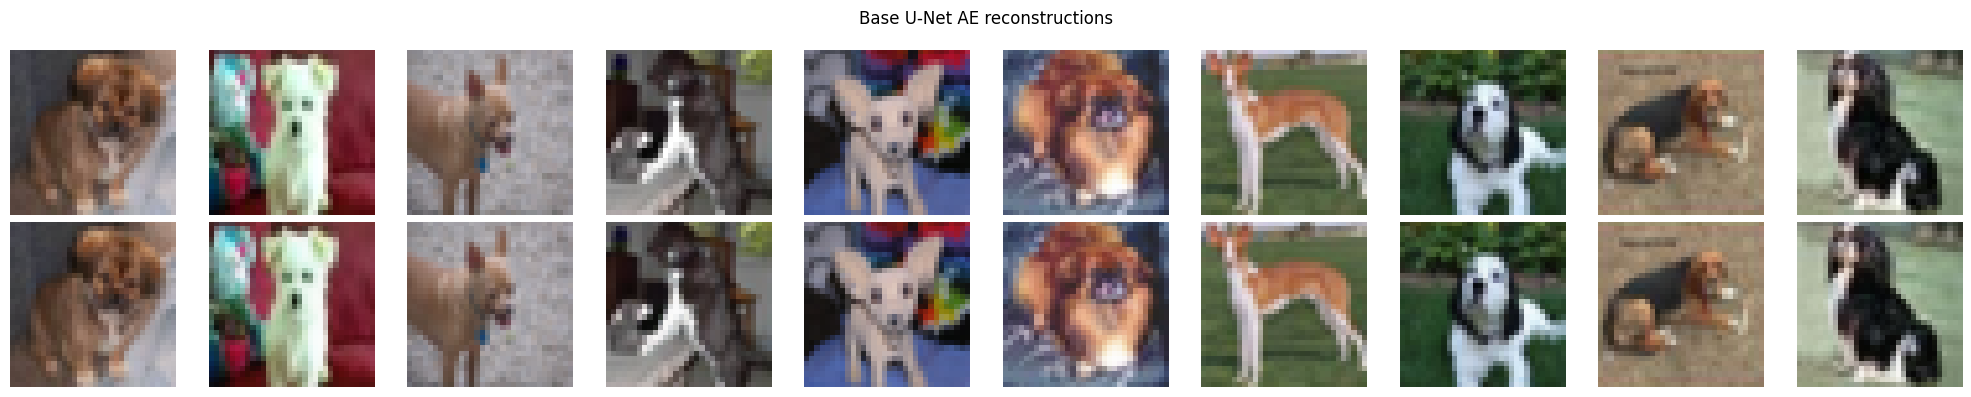

In [8]:
if LOCAL_TRAINING:
    base_history, base_time = train_reconstruction_model(
        base_model,
        base_loader,
        BASE_EPOCHS,
        LEARNING_RATE,
        "Base U-Net AE",
    )
else:
    base_history, base_time = [], 0.0
    print("Базовое обучение пропущено")

base_eval_loss = evaluate_reconstruction(base_model, adapt_eval_loader)
print("base dog eval loss:", round(base_eval_loss, 6))

torch.save(base_model.state_dict(), CHECKPOINTS_DIR / "base_unet_autoencoder.pt")
show_reconstructions(base_model, adapt_eval_loader, "Base U-Net AE reconstructions", save_name="base_reconstructions.png")


## LoRA-подобная адаптация

Базовая U-Net-модель заморожена. Обучается только небольшой residual-adapter. Это демонстрирует принцип лёгкой адаптации: меняется малая часть параметров, а основная модель остаётся неизменной.


LoRA-style total params: 766374
LoRA-style trainable params: 2819
trainable ratio: 0.3678 %


LoRA-style epoch 1/12:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA-style epoch [1/12] loss: 0.003352


LoRA-style epoch 2/12:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA-style epoch [2/12] loss: 0.003092


...

LoRA-style epoch [10/12] loss: 0.002025


LoRA-style epoch 11/12:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA-style epoch [11/12] loss: 0.001996


LoRA-style epoch 12/12:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA-style epoch [12/12] loss: 0.001982
LoRA-style dog eval loss: 0.001962


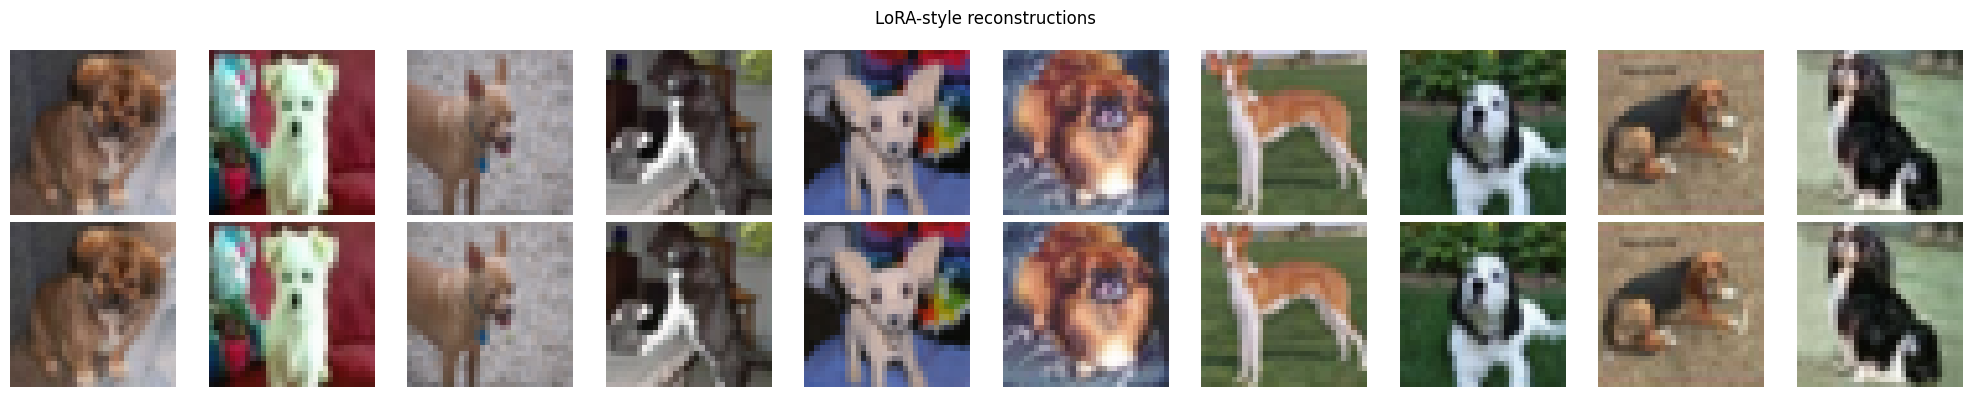

In [9]:
lora_model = LoRAStyleModel(copy.deepcopy(base_model)).to(DEVICE)

lora_total, lora_trainable = count_parameters(lora_model)
print("LoRA-style total params:", lora_total)
print("LoRA-style trainable params:", lora_trainable)
print("trainable ratio:", round(lora_trainable / lora_total * 100, 4), "%")

if LOCAL_TRAINING:
    lora_history, lora_time = train_reconstruction_model(
        lora_model,
        adapt_loader,
        LORA_EPOCHS,
        LORA_LEARNING_RATE,
        "LoRA-style",
    )
else:
    lora_history, lora_time = [], 0.0

lora_eval_loss = evaluate_reconstruction(lora_model, adapt_eval_loader)
print("LoRA-style dog eval loss:", round(lora_eval_loss, 6))

torch.save(lora_model.state_dict(), CHECKPOINTS_DIR / "lora_style_adapter.pt")
show_reconstructions(lora_model, adapt_eval_loader, "LoRA-style reconstructions", save_name="lora_reconstructions.png")


## DreamBooth-подобная адаптация

Копия базовой модели дообучается целиком на 20 изображениях `sks dog`. Это демонстрирует более тяжёлую персонализацию: больше обучаемых параметров, выше риск переобучения, но сильнее подстройка под объект.


DreamBooth-style total params: 763555
DreamBooth-style trainable params: 763555
trainable ratio: 100.0 %


DreamBooth-style epoch 1/12:   0%|          | 0/1 [00:00<?, ?it/s]

DreamBooth-style epoch [1/12] loss: 0.000768


DreamBooth-style epoch 2/12:   0%|          | 0/1 [00:00<?, ?it/s]

DreamBooth-style epoch [2/12] loss: 0.009111


...

DreamBooth-style epoch [10/12] loss: 0.001741


DreamBooth-style epoch 11/12:   0%|          | 0/1 [00:00<?, ?it/s]

DreamBooth-style epoch [11/12] loss: 0.001343


DreamBooth-style epoch 12/12:   0%|          | 0/1 [00:00<?, ?it/s]

DreamBooth-style epoch [12/12] loss: 0.001242
DreamBooth-style dog eval loss: 0.00157


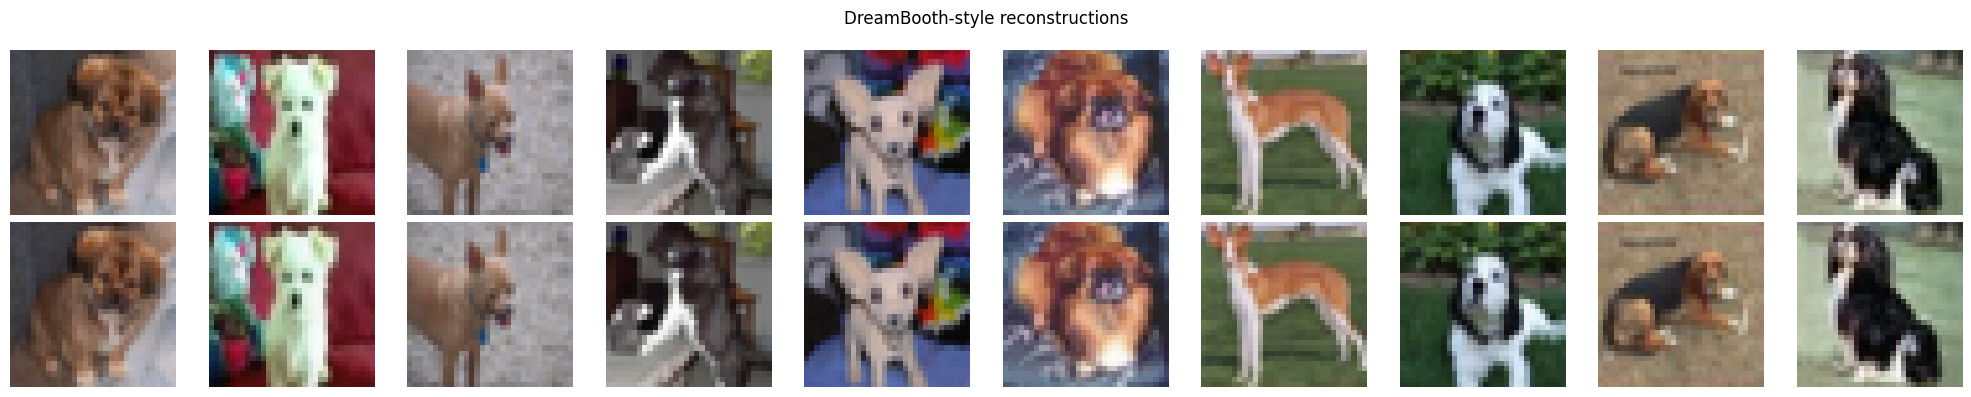

In [10]:
dreambooth_model = copy.deepcopy(base_model).to(DEVICE)

for param in dreambooth_model.parameters():
    param.requires_grad = True

db_total, db_trainable = count_parameters(dreambooth_model)
print("DreamBooth-style total params:", db_total)
print("DreamBooth-style trainable params:", db_trainable)
print("trainable ratio:", round(db_trainable / db_total * 100, 4), "%")

if LOCAL_TRAINING:
    dreambooth_history, dreambooth_time = train_reconstruction_model(
        dreambooth_model,
        adapt_loader,
        DREAMBOOTH_EPOCHS,
        DREAMBOOTH_LEARNING_RATE,
        "DreamBooth-style",
    )
else:
    dreambooth_history, dreambooth_time = [], 0.0

dreambooth_eval_loss = evaluate_reconstruction(dreambooth_model, adapt_eval_loader)
print("DreamBooth-style dog eval loss:", round(dreambooth_eval_loss, 6))

torch.save(dreambooth_model.state_dict(), CHECKPOINTS_DIR / "dreambooth_style_model.pt")
show_reconstructions(dreambooth_model, adapt_eval_loader, "DreamBooth-style reconstructions", save_name="dreambooth_reconstructions.png")


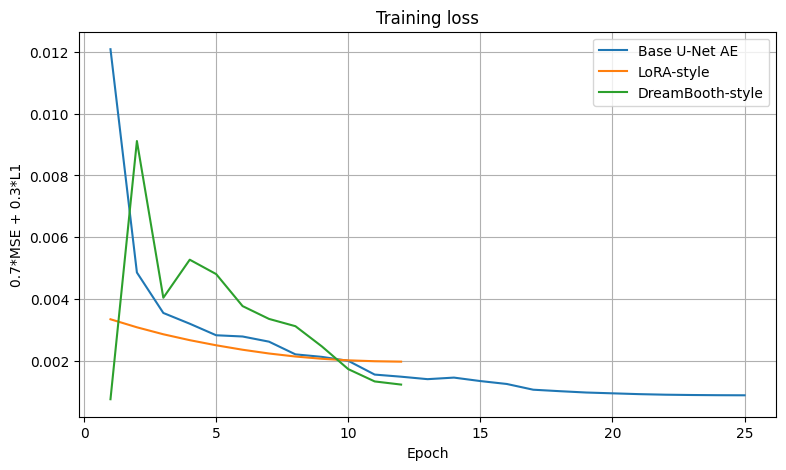

In [11]:
plt.figure(figsize=(9, 5))

if base_history:
    plt.plot(range(1, len(base_history) + 1), base_history, label="Base U-Net AE")
if lora_history:
    plt.plot(range(1, len(lora_history) + 1), lora_history, label="LoRA-style")
if dreambooth_history:
    plt.plot(range(1, len(dreambooth_history) + 1), dreambooth_history, label="DreamBooth-style")

plt.xlabel("Epoch")
plt.ylabel("0.7*MSE + 0.3*L1")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
results = pd.DataFrame([
    {
        "Model": "Base U-Net AE",
        "Trainable params": trainable,
        "Total params": total,
        "Trainable ratio, %": round(trainable / total * 100, 4),
        "Eval loss on dog": round(base_eval_loss, 6),
        "Training time, sec": round(base_time, 2),
    },
    {
        "Model": "LoRA-style",
        "Trainable params": lora_trainable,
        "Total params": lora_total,
        "Trainable ratio, %": round(lora_trainable / lora_total * 100, 4),
        "Eval loss on dog": round(lora_eval_loss, 6),
        "Training time, sec": round(lora_time, 2),
    },
    {
        "Model": "DreamBooth-style",
        "Trainable params": db_trainable,
        "Total params": db_total,
        "Trainable ratio, %": round(db_trainable / db_total * 100, 4),
        "Eval loss on dog": round(dreambooth_eval_loss, 6),
        "Training time, sec": round(dreambooth_time, 2),
    },
])

display(results)
results.to_csv(RESULTS_DIR / "comparison_results.csv", index=False)


,Model,Trainable params,Total params,"Trainable ratio, %",Eval loss on dog,"Training time, sec"
0,Base U-Net AE,763555,763555,100.0000,0.000849,1247.77
1,LoRA-style,2819,766374,0.3678,0.001962,0.84
2,DreamBooth-style,763555,763555,100.0000,0.001570,1.02


## Выводы

1. В улучшенной локальной версии U-Net-подобная архитектура со skip-связями даёт более качественные реконструкции, чем простой автоэнкодер.
2. LoRA-подобная адаптация обучает только небольшую добавочную часть модели. Это снижает число обучаемых параметров и делает подход компактным.
3. DreamBooth-подобная адаптация обучает всю копию модели. Она сильнее подстраивается под конкретные изображения, но требует больше вычислений и сильнее рискует переобучиться.
4. В настоящем Stable Diffusion LoRA обычно удобнее для практики: адаптеры занимают меньше места, быстрее обучаются и могут подключаться к одной базовой модели.
5. Prior preservation в DreamBooth нужен, чтобы модель после обучения на `sks dog` не забывала общий класс `dog`.
6. Ограничение этой локальной демонстрации: CIFAR-10 имеет размер 32×32, поэтому даже улучшенные результаты не будут выглядеть как настоящая Stable Diffusion-генерация.
